# Export morphological parameters
- This script is used to export morphological parameters and temperature reductions.
- Simulations: CNTL, TranAlbe

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import os
home_path = '/gws/ssde/j25a/duicv/yuansun/'

In [21]:
date_start = '05-29'
date_end = '08-27'
year = 2038

start = datetime.strptime(f"{year}-{date_start}", "%Y-%m-%d")
end = datetime.strptime(f"{year}-{date_end}", "%Y-%m-%d")
dates = []
current_date = start
while current_date <= end:
    dates.append(current_date.strftime("%Y-%m-%d"))
    current_date += timedelta(days=5)

print(dates)

['2038-05-29', '2038-06-03', '2038-06-08', '2038-06-13', '2038-06-18', '2038-06-23', '2038-06-28', '2038-07-03', '2038-07-08', '2038-07-13', '2038-07-18', '2038-07-23', '2038-07-28', '2038-08-02', '2038-08-07', '2038-08-12', '2038-08-17', '2038-08-22', '2038-08-27']


In [ ]:
ds_HK_mask = xr.open_dataset('../../HK/mask/mask_HK_lat_lon.nc')
ds_HK_mask_urban = ds_HK_mask['PCT_URBAN']>0
ds_HK_mask_urban

<xarray.DataArray 'PCT_URBAN' (lat: 60, lon: 60)> Size: 4kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * lat      (lat) float64 480B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69
  * lon      (lon) float64 480B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5

In [82]:
## jja mean, day
mete_var_list = ['TSA_U', 'TG_U']
cntl_jja_day = []
delta_jja_day = []
for date in dates:
    cntl_filename = f'{home_path}0_wrf-cstm_GM-HK/runs/TranUrbAlb_HK/runs/d04_cntl/archive_ctsm/lnd/cntl_albe4.clm2.h0.{date}-03600.nc'
    tran_albe_filename = f'{home_path}0_wrf-cstm_GM-HK/runs/TranUrbAlb_HK/runs/d04_tran_albe/archive_ctsm/lnd/tran_albe4.clm2.h0.{date}-03600.nc'
    ds_cntl = xr.open_dataset(cntl_filename)
    ds_tran_albe = xr.open_dataset(tran_albe_filename)
    ds_cntl_sel = ds_cntl[mete_var_list].isel(time=np.arange(5, 120, 24))
    ds_tran_albe_sel = ds_tran_albe[mete_var_list].isel(time=np.arange(5, 120, 24))
    ds_delta_sel = ds_tran_albe_sel - ds_cntl_sel
    if date ==f'{year}-05-29':
        ds_delta_jja = ds_delta_sel.sel(time=ds_delta_sel.time.dt.month == 6)
        ds_cntl_jja = ds_cntl_sel.sel(time=ds_delta_sel.time.dt.month == 6)
    else:
        ds_delta_jja = ds_delta_sel
        ds_cntl_jja = ds_cntl_sel
    delta_jja_day.append(ds_delta_jja)
    cntl_jja_day.append(ds_cntl_jja) 
ds_delta_jja_mean = xr.concat(delta_jja_day, dim='time').mean(dim='time').where(ds_HK_mask_urban)
ds_cntl_jja_mean = xr.concat(cntl_jja_day, dim='time').mean(dim='time').where(ds_HK_mask_urban)
delta_jja_filename = f'./data_for_figure/changes_{year}_JJA_day.nc'
if os.path.isfile(delta_jja_filename):
    os.remove(delta_jja_filename)
ds_delta_jja_mean.to_netcdf(delta_jja_filename)
cntl_jja_filename = f'./data_for_figure/cntl_{year}_JJA_day.nc'
if os.path.isfile(cntl_jja_filename):
    os.remove(cntl_jja_filename)   
ds_cntl_jja_mean.to_netcdf(cntl_jja_filename)    

In [61]:
ds_surf = xr.open_dataset('../../HK/surface_data/usurf/Usurf_surfdata_HK_1.2x1.2_SSP5-8.5_2035_78pfts_c250811.nc')
ds_surf_urban_morp = ds_surf[['HT_ROOF', 'CANYON_HWR', 'WTLUNIT_ROOF', 'WTROAD_PERV', 'PCT_URBAN', 'LANDFRAC_PFT']].sel(numurbl=2)
ds_surf_urban_morp = ds_surf_urban_morp.rename({'lsmlat': 'lat', 'lsmlon': 'lon'}).assign_coords(lat=ds_HK_mask_urban.lat, lon=ds_HK_mask_urban.lon)
ds_surf_urban_morp = ds_surf_urban_morp.where(ds_HK_mask_urban)
ds_surf_urban_morp

<xarray.Dataset> Size: 174kB
Dimensions:       (lat: 60, lon: 60)
Coordinates:
  * lat           (lat) float64 480B 22.06 22.07 22.08 ... 22.67 22.68 22.69
  * lon           (lon) float64 480B 113.8 113.8 113.8 ... 114.4 114.5 114.5
Data variables:
    HT_ROOF       (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    CANYON_HWR    (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    WTLUNIT_ROOF  (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    WTROAD_PERV   (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    PCT_URBAN     (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    LANDFRAC_PFT  (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
Attributes: (12/46)
    Conventions:                              NCAR-CESM
    History_Log:                              created on: 08-15-25 18:13:26
    Source:                                   Community Land Model: CLM5
    Version:                                  custom-build
    Dataset_Version:                          5.3
    Logname:                                  yuansun
    ...                                       ...
    lai_raw_data_file_name:                   mksrf_landuse_ctsm53_pftlai_CLI...
    soil_color_raw_data_file_name:            mksrf_landuse_ctsm53_soilcolor_...
    soil_texture_mapunit_raw_data_file_name:  mksrf_soil_mapunits_5x5min_WISE...
    soil_texture_lookup_raw_data_file_name:   mksrf_soil_lookup.10level.WISE....
    fmax_raw_data_file_name:                  mksrf_fmax_0.125x0.125_c200220.nc
    VOC_EF_raw_data_file_name:                mksrf_vocef_0.5x0.5_simyr2000.c...

In [90]:
normalized_delta = ds_delta_jja_mean['TSA_U'] / (ds_cntl_jja_mean['TSA_U'] * ds_surf_urban_morp['WTLUNIT_ROOF'])
normalized_delta

<xarray.DataArray (lat: 60, lon: 60)> Size: 29kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lon      (lon) float32 240B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5
  * lat      (lat) float32 240B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69

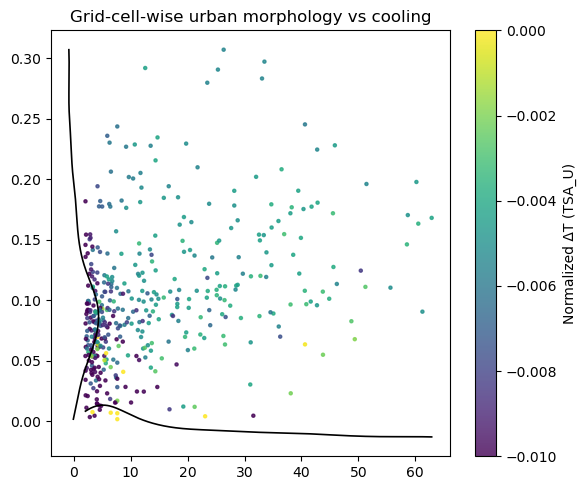

In [98]:
x = ds_surf_urban_morp['HT_ROOF']
#y = ds_surf_urban_morp['CANYON_HWR']
y = ds_surf_urban_morp['WTLUNIT_ROOF']
#y = ds_surf_urban_morp['WTROAD_PERV']
c = normalized_delta
x, y, c = xr.align(x, y, c, join='inner')
x1 = x.values.ravel()
y1 = y.values.ravel()
c1 = c.values.ravel()
mask = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(c1)

xv = x1[mask]
yv = y1[mask]
cv = c1[mask]
plt.figure(figsize=(6, 5))

sc = plt.scatter(xv, yv, c=cv, s=5, alpha=0.8, vmax=0, vmin=-0.01)

from scipy.stats import gaussian_kde

# ---- KDE for x ----
kde_x = gaussian_kde(xv)
x_grid = np.linspace(xv.min(), xv.max(), 300)
kx = kde_x(x_grid)

# normalize & scale
kx = kx / kx.max()
y_min, y_max = plt.ylim()
kx_scaled = y_min + 0.08 * (y_max - y_min) * kx

plt.plot(x_grid, kx_scaled, color='k', lw=1.2)

# ---- KDE for y ----
kde_y = gaussian_kde(yv)
y_grid = np.linspace(yv.min(), yv.max(), 300)
ky = kde_y(y_grid)

ky = ky / ky.max()
x_min, x_max = plt.xlim()
ky_scaled = x_min + 0.08 * (x_max - x_min) * ky

plt.plot(ky_scaled, y_grid, color='k', lw=1.2)

plt.colorbar(sc, label='Normalized ΔT (TSA_U)')
plt.title('Grid-cell-wise urban morphology vs cooling')

plt.tight_layout()
plt.show()

In [96]:
from scipy.stats import spearmanr, pearsonr

# HT_ROOF vs normalized ΔT
r_ht, p_ht = spearmanr(xv, cv)

# CANYON_HWR vs normalized ΔT
r_hw, p_hw = spearmanr(yv, cv)

print(f"Spearman HT_ROOF–ΔT: r={r_ht:.3f}, p={p_ht:.3e}")
print(f"Spearman H/W–ΔT:    r={r_hw:.3f}, p={p_hw:.3e}")

Spearman HT_ROOF–ΔT: r=0.283, p=2.684e-09
Spearman H/W–ΔT:    r=-0.342, p=3.294e-13
